In [1]:
%matplotlib widget
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0,'../st_validate')
import datetime
import os
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from scipy.stats import gaussian_kde
from skimage.transform import resize
from skimage.color import rgb2gray
# import pickle
# import sta_validate # import functions for phantom creation and sta tests
# import sta # import functions for computing structure tensors and angles
# import periodic_kmeans # import functions for angle clustering in 2D
# import utils
# import visualize

SMALL_SIZE = 10
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

HOME = "/home/brysongray/structure_tensor_validation/"
DATE = datetime.datetime.today().strftime("%m-%d-%y")
g_sigmas = np.linspace(start=0.15, stop=2.5, num=10)
w_sigmas = np.linspace(start=0.0, stop=5.0, num=10)

## Variable noise analysis

In [67]:
errors_path = "/home/brysongray/bmap/fibermetric/st_validation/sta_3d_var_noise_out"
# errors_path = "/nafs/dtward/bryson/fibermetric/st_validation/sta_2d_out_7-25-24"

errors_files = os.listdir(errors_path)
all_dataframes = []

for file in errors_files:
    file_path = os.path.join(errors_path, file)
    df = pd.read_pickle(file_path)
    all_dataframes.append(df)

combined_dataframe = pd.concat(all_dataframes, ignore_index=True)

In [4]:
combined_dataframe.iloc[0]

derivative_sigma                                        0.15
tensor_sigma                                             0.0
AI                                                       1.0
period                                                  13.0
width                                                    1.0
angles              [0.3649324799624507, 1.5231964381041423]
noise                                               0.033333
error                                               5.107683
Name: 0, dtype: object

In [21]:
derivative_sigmas = np.linspace(start=0.15, stop=2.5, num=10)
tensor_sigmas = np.linspace(start=0.0, stop=5.0, num=10)
print(derivative_sigmas)
print(tensor_sigmas)

[0.15       0.41111111 0.67222222 0.93333333 1.19444444 1.45555556
 1.71666667 1.97777778 2.23888889 2.5       ]
[0.         0.55555556 1.11111111 1.66666667 2.22222222 2.77777778
 3.33333333 3.88888889 4.44444444 5.        ]


In [68]:
# median over angles
median_error_over_angle_AI1 = combined_dataframe[combined_dataframe["AI"]==1.0].groupby(['derivative_sigma', 'tensor_sigma', 'noise'], as_index=False)['error'].median()
median_error_over_angle_AI3 = combined_dataframe[combined_dataframe["AI"]==3.0].groupby(['derivative_sigma', 'tensor_sigma', 'noise'], as_index=False)['error'].median()
min_error_over_sigma_AI1 = median_error_over_angle_AI1.loc[median_error_over_angle_AI1.groupby('noise')['error'].idxmin()]
min_error_over_sigma_AI3 = median_error_over_angle_AI3.loc[median_error_over_angle_AI3.groupby('noise')['error'].idxmin()]
print(min_error_over_sigma_AI1)
print(min_error_over_sigma_AI3)

     derivative_sigma  tensor_sigma     noise     error
510          1.455556      0.555556  0.000000  1.076975
611          1.716667      0.555556  0.033333  2.387989
522          1.455556      1.111111  0.066667  2.849230
623          1.716667      1.111111  0.100000  3.009556
624          1.716667      1.111111  0.133333  3.446748
225          0.672222      1.111111  0.166667  3.423530
326          0.933333      1.111111  0.200000  3.662546
327          0.933333      1.111111  0.233333  3.473906
438          1.194444      1.666667  0.266667  3.714830
539          1.455556      1.666667  0.300000  3.933394
     derivative_sigma  tensor_sigma     noise      error
220          0.672222      1.111111  0.000000  16.679806
431          1.194444      1.666667  0.033333  24.131411
642          1.716667      2.222222  0.066667  25.759566
653          1.716667      2.777778  0.100000  26.708472
644          1.716667      2.222222  0.133333  27.873826
645          1.716667      2.222222  0.166

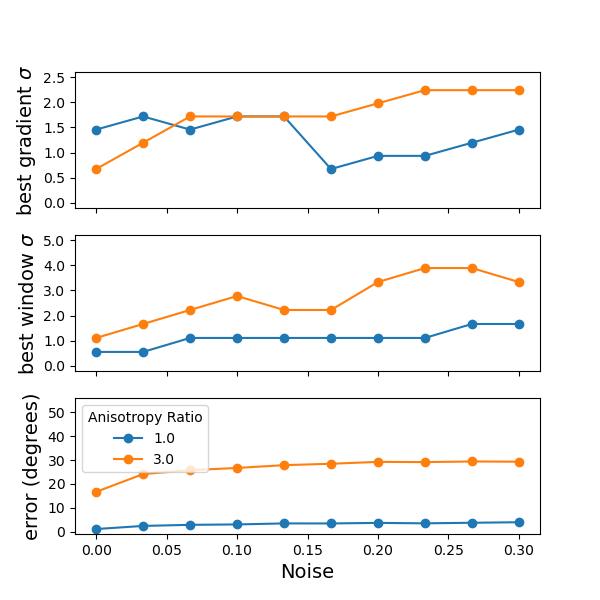

In [71]:
# plot the best sigma 1 and best sigma 2 versus the anisotropy ratio
fig, axs = plt.subplots(3, figsize=(6,6), sharex=True)
axs[0].plot(min_error_over_sigma_AI1['noise'], min_error_over_sigma_AI1['derivative_sigma'], marker='o')
axs[0].plot(min_error_over_sigma_AI3['noise'], min_error_over_sigma_AI3['derivative_sigma'], marker='o')
axs[0].set_ylim(-0.1,2.6)
axs[0].set_yticks(np.arange(0.0,3.0,0.5))
axs[0].set_ylabel(r'best gradient $\sigma$')
axs[1].plot(min_error_over_sigma_AI1['noise'], min_error_over_sigma_AI1['tensor_sigma'], marker='o')
axs[1].plot(min_error_over_sigma_AI3['noise'], min_error_over_sigma_AI3['tensor_sigma'], marker='o')
axs[1].set_ylim(-0.2,5.2)
yticklabels = [f'{y:.1f}'for y in np.arange(0.0,6.0,1.0)]
axs[1].set_yticks(np.arange(0.0,6.0,1.0))
axs[1].set_yticklabels(yticklabels)
axs[1].set_ylabel(r'best window $\sigma$')
axs[2].plot(min_error_over_sigma_AI1['noise'], min_error_over_sigma_AI1['error'], marker='o', label='1.0')
axs[2].plot(min_error_over_sigma_AI3['noise'], min_error_over_sigma_AI3['error'], marker='o', label='3.0')
axs[2].set_ylim(-1,56)
axs[2].set_yticks(np.arange(0,55,10))
axs[2].set_ylabel('error (degrees)')
axs[2].set_xlabel('Noise')
axs[2].legend(['1.0', '3.0'], title="Anisotropy Ratio")
fig.savefig('../outputs/figures/3d_error_vs_noise_.png')
plt.show()

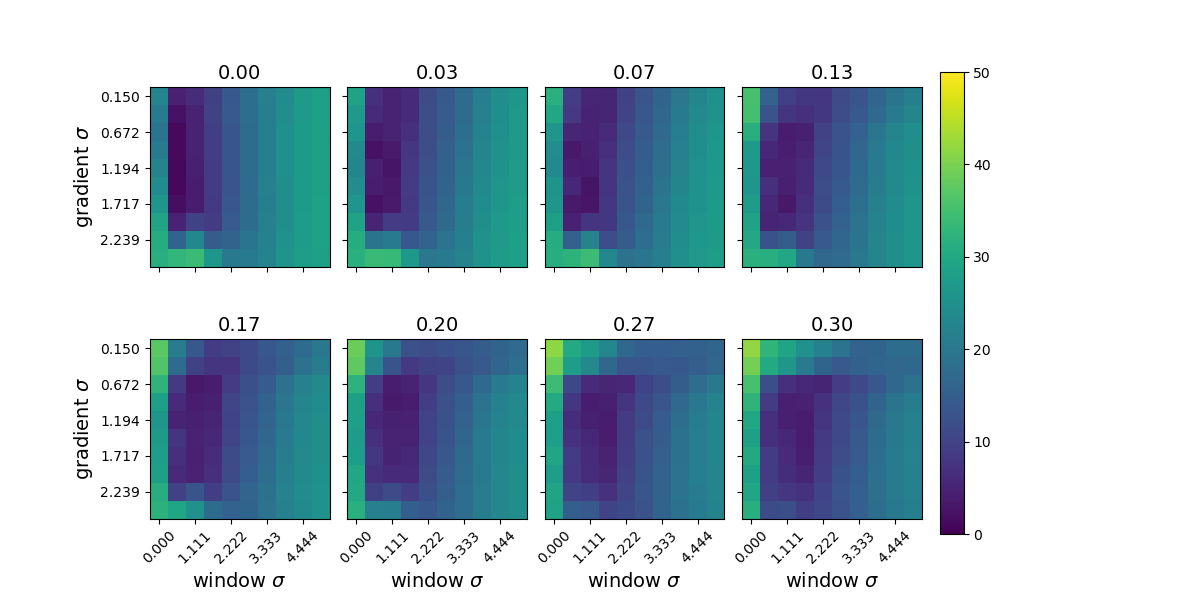

In [70]:
errors = median_error_over_angle_AI1['error'].values.reshape((len(median_error_over_angle_AI1["derivative_sigma"].unique()), len(median_error_over_angle_AI1["tensor_sigma"].unique()), len(median_error_over_angle_AI1['noise'].unique())))

rows = 2
cols = 4
vm = 50
fig, axs = plt.subplots(rows,cols, figsize=(12,6), sharex=True, sharey=True)
for i,j in enumerate([0,1,2,4,5,6,8,9]):
    error = errors[...,j]
    axs[i//cols,i%cols].imshow(error, vmin=0, vmax=vm)
    axs[i//cols,i%cols].set_title(f"{median_error_over_angle_AI1['noise'].unique()[j]:.2f}")
    # set x tick labels
    # set the locations of the xticks and yticks
    xticklabels = [f'{t:.3f}' for t in tensor_sigmas]
    yticklabels = [f'{d:.3f}' for d in derivative_sigmas]
    axs[i//cols, i%cols].set_xticks(np.arange(len(tensor_sigmas))[::2])
    axs[i//cols, i%cols].set_yticks(np.arange(len(derivative_sigmas))[::2])
    axs[i//cols, i%cols].set_xticklabels(xticklabels[::2], rotation=45)
    axs[i//cols, i%cols].set_yticklabels(yticklabels[::2])
    if i%cols==0:
        axs[i//cols,i%cols].set_ylabel(r'gradient $\sigma$')
    if i > cols * (rows-1) - 1:
        axs[i//cols,i%cols].set_xlabel(r'window $\sigma$')
    plt.subplots_adjust(wspace=0.1, hspace=0.2)
# add colorbar to the rightmean
cbar = fig.colorbar(axs[0,0].images[0], ax=axs, location='right', pad=0.02)
# fig.suptitle('2D Three Angles')

fig.savefig('../outputs/figures/heatmaps_3d_error_vs_noise_'+DATE+'.png')

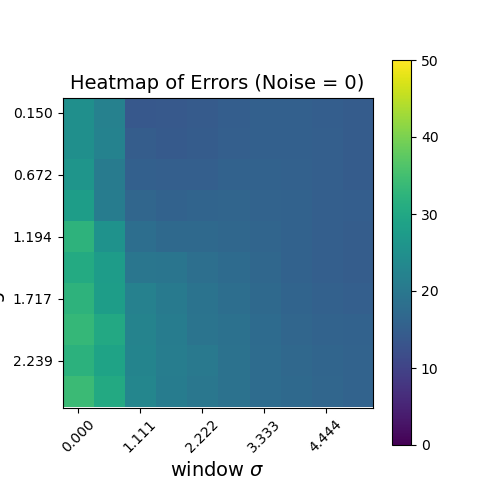

In [34]:
# Filter the dataframe for rows where noise is zero
# filtered_df = combined_dataframe[combined_dataframe['noise'] == 0]
filtered_df = combined_dataframe[(combined_dataframe['noise'] == 0) &
                                 (combined_dataframe["angles"].apply(lambda x: np.array(x).shape == (2,))) &
                                 (combined_dataframe['AI'] == 3.0)
                                 ]

# Group by derivative_sigma and tensor_sigma, and calculate the mean error
heatmap_data = filtered_df.groupby(['derivative_sigma', 'tensor_sigma'])['error'].median().unstack()

# Plot the heatmap
plt.figure(figsize=(5, 5))
xticklabels = [f"{x:.3f}" for x in tensor_sigmas]
yticklabels = [f"{x:.3f}" for x in derivative_sigmas]
plt.xticks(np.arange(len(xticklabels))[::2], labels=xticklabels[::2], rotation=45)
plt.yticks(np.arange(len(yticklabels))[::2], labels=yticklabels[::2])
plt.imshow(np.array(heatmap_data), vmin=0.0, vmax=50.0)
plt.title("Heatmap of Errors (Noise = 0)")
plt.xlabel(r"window $\sigma$")
plt.ylabel(r"gradient $\sigma$")
plt.colorbar()
plt.show()

In [35]:
print(f"min error: {np.array(heatmap_data).min()}\n"
      f"argmin: {np.array(heatmap_data).argmin()}")

min error: 13.727859414669938
argmin: 2


In [40]:
tensor_sigma_target = tensor_sigmas[2]
derivative_sigma_target = derivative_sigmas[1]
filtered_rows = combined_dataframe[
    (combined_dataframe["angles"].apply(lambda x: np.array(x).shape == (2,))) &
    (combined_dataframe['derivative_sigma'] == derivative_sigma_target) &
    (combined_dataframe['tensor_sigma'] == tensor_sigma_target) &
    (combined_dataframe['AI'] == 1.0)
]
AI_1 = filtered_rows.drop(columns=["derivative_sigma", "tensor_sigma", "AI", "period", "width", "angles"]).groupby(["noise"]).median()

In [36]:
tensor_sigma_target = tensor_sigmas[2]
derivative_sigma_target = derivative_sigmas[0]
filtered_rows = combined_dataframe[
    (combined_dataframe['derivative_sigma'] == derivative_sigma_target) & 
    (combined_dataframe['tensor_sigma'] == tensor_sigma_target) &
    (combined_dataframe['AI'] == 3.0)
]
AI_3 = filtered_rows.drop(columns=["derivative_sigma", "tensor_sigma", "AI", "period", "width", "angles"]).groupby(["noise"]).median()

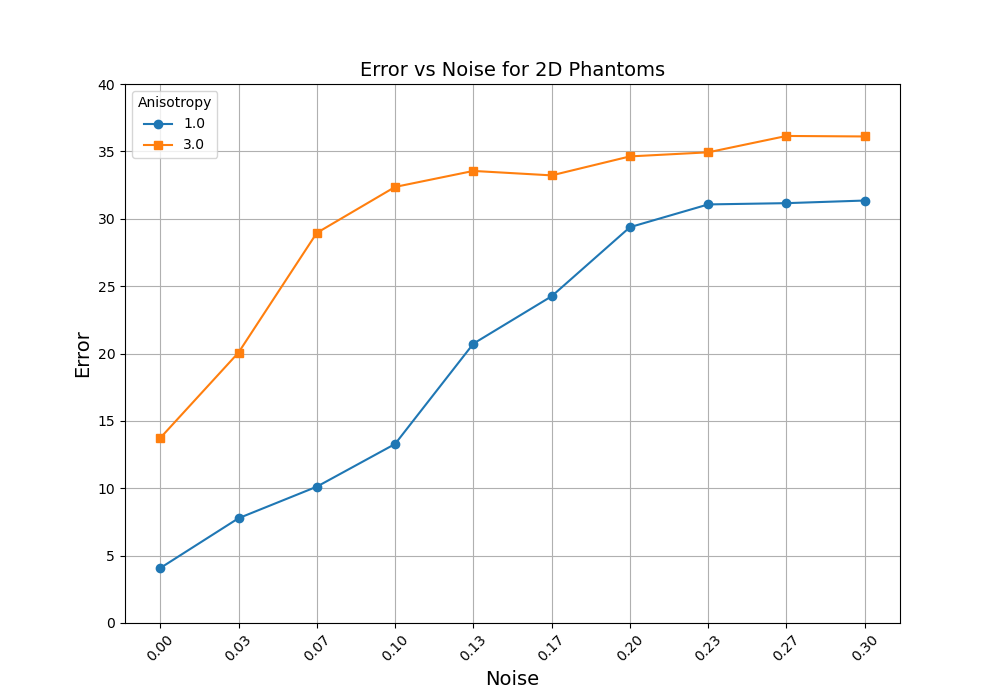

In [41]:
plt.figure(figsize=(10,7))
plt.plot(AI_1.index, AI_1['error'], label='1.0', marker='o')
plt.plot(AI_3.index, AI_3['error'], label='3.0', marker='s')
plt.xlabel('Noise')
plt.ylabel('Error')
plt.title('Error vs Noise for 2D Phantoms')
ticklabels = [f"{x:.2f}" for x in AI_1.index]
ticks = np.array(AI_1.index)
yticks = np.arange(0,45,5)
plt.yticks(yticks)
plt.xticks(ticks, labels=ticklabels, rotation=45)
legend = plt.legend(loc="upper left")
legend.set_title("Anisotropy")
plt.grid(True)
plt.show()

## Error vs Anisotropic Dimension Component Analysis

In [3]:
errors_path = "/home/brysongray/nafs/bryson/fibermetric/st_validation/sta_3d_out_7-25-24"
errors_files = os.listdir(errors_path)
all_dataframes = []

for file in errors_files:
    file_path = os.path.join(errors_path, file)
    df = pd.read_pickle(file_path)
    all_dataframes.append(df)

combined_dataframe = pd.concat(all_dataframes, ignore_index=True)

In [4]:
np.unique(combined_dataframe["AI"])

array([1.        , 2.        , 3.        , 4.        , 5.14285714,
       6.        , 7.2       , 8.        ])

In [25]:
filtered_rows = combined_dataframe[combined_dataframe["angles"].apply(lambda x: np.array(x).shape == (2,))]
# filtered_rows_AI_2 = filtered_rows[filtered_rows["AI"]==2.0]
# filtered_rows_AI_3 = filtered_rows[filtered_rows["AI"]==3.0]
# filtered_rows_AI_4 = filtered_rows[filtered_rows["AI"]==4.0]
# filtered_rows_AI_5 = filtered_rows[filtered_rows["AI"]==np.unique(combined_dataframe["AI"])[4]]
# filtered_rows_AI_6 = filtered_rows[filtered_rows["AI"]==6.0]
# filtered_rows_AI_7 = filtered_rows[filtered_rows["AI"]==7.2]
# filtered_rows_AI_8 = filtered_rows[filtered_rows["AI"]==8.0]

In [6]:
filtered_rows

,derivative_sigma,tensor_sigma,AI,period,width,angles,error
240000,0.15,0.000000,1.0,7.0,1.0,"[0.10501247782765949, 1.3498968770433821]",16.706709
240001,0.15,0.555556,1.0,7.0,1.0,"[0.10501247782765949, 1.3498968770433821]",0.268501
240002,0.15,1.111111,1.0,7.0,1.0,"[0.10501247782765949, 1.3498968770433821]",0.471223
240003,0.15,1.666667,1.0,7.0,1.0,"[0.10501247782765949, 1.3498968770433821]",0.582446
240004,0.15,2.222222,1.0,7.0,1.0,"[0.10501247782765949, 1.3498968770433821]",0.607158
...,...,...,...,...,...,...,...
479995,2.50,2.777778,8.0,13.0,1.0,"[2.3471598180330293, 0.3718074288765335]",1.712486
479996,2.50,3.333333,8.0,13.0,1.0,"[2.3471598180330293, 0.3718074288765335]",1.720728
479997,2.50,3.888889,8.0,13.0,1.0,"[2.3471598180330293, 0.3718074288765335]",1.695214
479998,2.50,4.444444,8.0,13.0,1.0,"[2.3471598180330293, 0.3718074288765335]",1.659331


In [22]:
filtered_rows['angle_0'] = filtered_rows['angles'].apply(lambda x: x[0])
grouped_by_angle_0 = filtered_rows.drop(columns=["derivative_sigma", "tensor_sigma", "period", "width", "angles"]).groupby(['angle_0', 'AI'], as_index=False).median()
# shift the angle_0 values to be between 0 and 90
grouped_by_angle_0['angle_0'] = grouped_by_angle_0['angle_0'].apply(lambda x: np.pi - x if x > np.pi/2 else x)

/tmp/ipykernel_2327750/3199303416.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_rows['angle_0'] = filtered_rows['angles'].apply(lambda x: x[0])


In [20]:
grouped_by_angle_0['AI'].unique()

array([1.        , 2.        , 3.        , 4.        , 5.14285714,
       6.        , 7.2       , 8.        ])

In [23]:
grouped_by_angle_0.iloc[:5]

,angle_0,AI,error
0,0.105012,1.000000,0.388605
1,0.105012,2.000000,0.348630
2,0.105012,3.000000,0.320253
3,0.105012,4.000000,0.304271
4,0.105012,5.142857,0.301120


KeyboardInterrupt: 

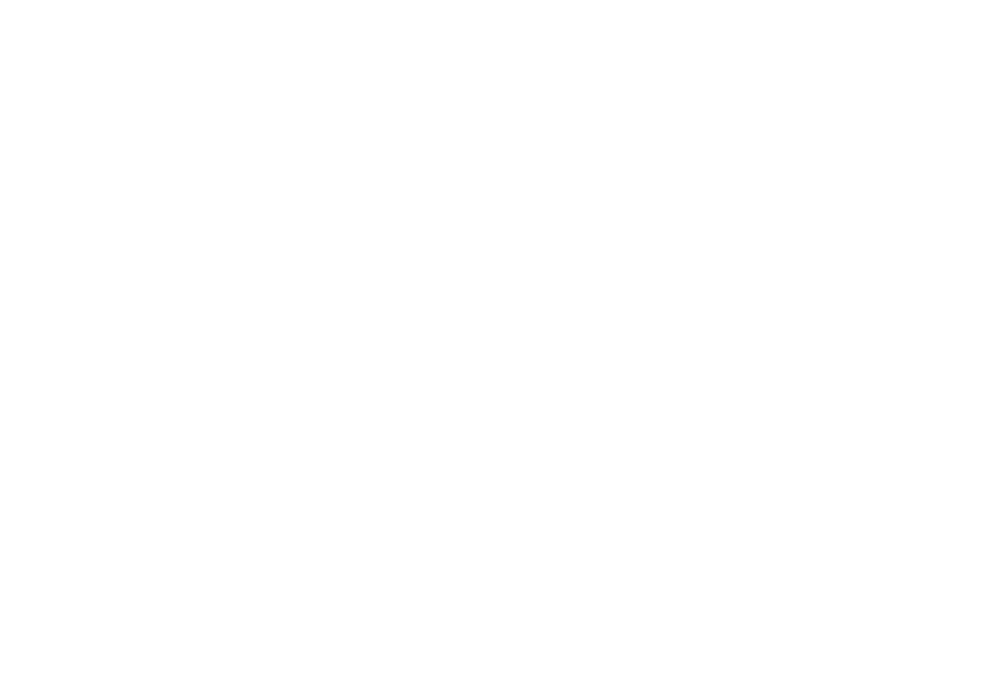

In [24]:
x = np.linspace(0, 90, 100)
plt.figure(figsize=(10,7))
for n in np.unique(grouped_by_angle_0['AI'])[1::2]:
    error_n = grouped_by_angle_0[grouped_by_angle_0['AI'] == n]
    kde = gaussian_kde(error_n['angle_0']* 180/np.pi)
    y = kde(x)
    plt.plot(x, y, label=f"{n}")
plt.title("Error vs Angle Relative to Low Resolution Dimension")
plt.ylabel("Error (degrees)")
plt.xlabel("Angle (degrees)")
legend = plt.legend()
legend.set_title("Anisotropy ratio")
plt.show()

In [26]:
filtered_rows['angle_0'] = filtered_rows['angles'].apply(lambda x: x[0])
grouped_by_angle_0 = filtered_rows.drop(columns=["derivative_sigma", "tensor_sigma", "period", "width", "angles"]).groupby(['angle_0', 'AI'], as_index=False).median()

/tmp/ipykernel_2327750/3228641029.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_rows['angle_0'] = filtered_rows['angles'].apply(lambda x: x[0])


In [27]:
grouped_by_angle_0.iloc[5]

angle_0    0.105012
AI         6.000000
error      0.304962
Name: 5, dtype: float64

In [28]:
# Define the bin size
bin_size = 5

# Create bins for angle_0
grouped_by_angle_0['angle_bin'] = ((grouped_by_angle_0['angle_0'] * 180 / np.pi) // bin_size) * bin_size
grouped_by_angle_0['angle_bin'] = [(180.0 - x if x > 90.0 else x) for x in grouped_by_angle_0['angle_bin']]

# Group by angle_bin and AI, then calculate the mean error
binned_data = grouped_by_angle_0.groupby(['angle_bin', 'AI'], as_index=False)['error'].mean()

binned_data

,angle_bin,AI,error
0,5.0,1.000000,0.388605
1,5.0,2.000000,0.348630
2,5.0,3.000000,0.320253
3,5.0,4.000000,0.304271
4,5.0,5.142857,0.301120
...,...,...,...
131,90.0,4.000000,1.388076
132,90.0,5.142857,2.254901
133,90.0,6.000000,2.864975
134,90.0,7.200000,4.165811


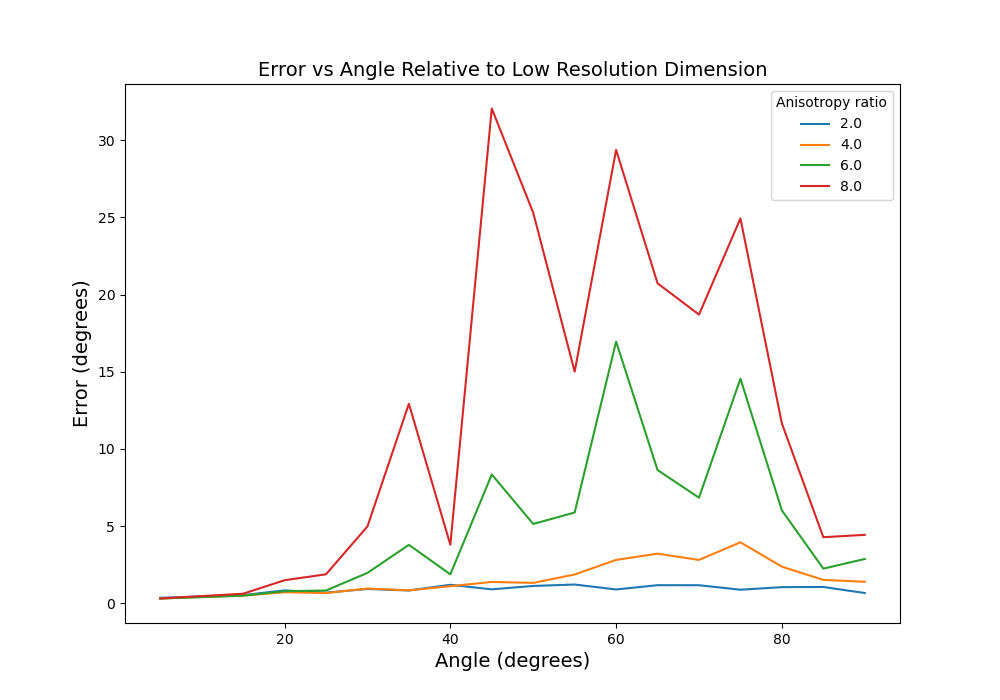

In [31]:
# plot error vs angle_0
# angle = grouped_by_angle_0["angle_0"].unique() * 180/np.pi
angle = binned_data["angle_bin"].unique()

plt.figure(figsize=(10,7))
for n in np.unique(combined_dataframe["AI"])[1::2]:
    # error = grouped_by_angle_0[grouped_by_angle_0["AI"]==n]["error"]
    error = binned_data[binned_data["AI"]==n]["error"]
    # Smooth the error using a rolling mean
    # error_smooth = error.rolling(window=3, center=True, min_periods=1).mean()
    plt.plot(angle, error, label=f"{n}")
    
plt.title("Error vs Angle Relative to Low Resolution Dimension")
plt.ylabel("Error (degrees)")
plt.xlabel("Angle (degrees)")
legend = plt.legend()
legend.set_title("Anisotropy ratio")
plt.show()

In [30]:
error

7       0.304594
15      0.614401
23      1.489003
31      1.873036
39      4.974219
47     12.924711
55      3.785049
63     32.061784
71     25.301994
79     15.005879
87     29.379018
95     20.732377
103    18.703780
111    24.936897
119    11.648891
127     4.276749
135     4.429977
Name: error, dtype: float64

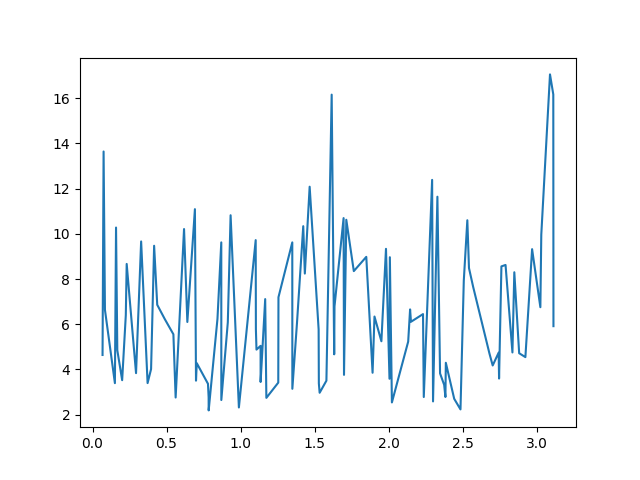

In [59]:
# plot error vs angle_1
angle = grouped_by_angle_1.index
error = grouped_by_angle_1["mean_err"]

plt.figure()
plt.plot(angle, error)
plt.show()

In [21]:
angles = np.stack(filtered_rows["angles"])
theta = angles[:,0]
phi = angles[:,1]
errors = np.array(filtered_rows["mean_err"])

In [25]:
np.unique(theta, return_counts=True)

(array([0.10501248, 0.2855414 , 0.30909004, 0.34109466, 0.42213962,
        0.52681012, 0.53148245, 0.56626805, 0.57294834, 0.5905425 ,
        0.68351658, 0.74472993, 0.76215472, 0.79270801, 0.80373806,
        0.8105568 , 0.81687111, 0.83244322, 0.87785638, 0.88206161,
        0.97568944, 0.98036845, 1.01669658, 1.02759841, 1.02993651,
        1.0431882 , 1.07090432, 1.08917019, 1.09650466, 1.11126442,
        1.17905937, 1.20666466, 1.22059478, 1.22155858, 1.23634147,
        1.26694186, 1.2929691 , 1.33185765, 1.35819958, 1.36653447,
        1.37295951, 1.39072774, 1.43610942, 1.43854648, 1.44213646,
        1.47115575, 1.51001204, 1.53572806, 1.54688415, 1.59434319,
        1.59667101, 1.60073075, 1.60538347, 1.62600545, 1.6767581 ,
        1.67908146, 1.69151145, 1.74757812, 1.74939319, 1.76696101,
        1.7943213 , 1.81171368, 1.84256195, 1.84396009, 1.86732621,
        1.88021893, 1.89323264, 1.90939246, 1.92502945, 1.94093602,
        1.97249986, 2.01498017, 2.07504785, 2.07

In [ ]:
plt.figure()
plt.plot()

array([25.30252775, 11.34639293,  3.00916771, ...,  7.86979116,
        7.98359389,  8.06878195], shape=(240000,))

## Variable Widths

In [37]:
errors_path = "/home/brysongray/bmap/fibermetric/st_validation/sta_3d_var_width_out"
errors_files = os.listdir(errors_path)
all_dataframes = []

for file in errors_files:
    file_path = os.path.join(errors_path, file)
    df = pd.read_pickle(file_path)
    all_dataframes.append(df)

combined_dataframe = pd.concat(all_dataframes, ignore_index=True)


In [29]:
combined_dataframe.iloc[0]

derivative_sigma                                         0.15
tensor_sigma                                              0.0
AI                                                        3.0
period                                                   20.0
width                                                     3.5
angles              [0.17453292519943295, 1.4914631789769726]
error                                                5.772727
Name: 0, dtype: object

In [8]:
combined_dataframe["derivative_sigma"].unique()

array([0.15      , 0.41111111, 0.67222222, 0.93333333, 1.19444444,
       1.45555556, 1.71666667, 1.97777778, 2.23888889, 2.5       ])

In [38]:
# median over angles
median_error_over_angle_AI1 = combined_dataframe[combined_dataframe["AI"]==1.0].groupby(['derivative_sigma', 'tensor_sigma', 'width'], as_index=False)['error'].median()
median_error_over_angle_AI3 = combined_dataframe[combined_dataframe["AI"]==3.0].groupby(['derivative_sigma', 'tensor_sigma', 'width'], as_index=False)['error'].median()
min_error_over_sigma_AI1 = median_error_over_angle_AI1.loc[median_error_over_angle_AI1.groupby('width')['error'].idxmin()]
min_error_over_sigma_AI3 = median_error_over_angle_AI3.loc[median_error_over_angle_AI3.groupby('width')['error'].idxmin()]
print(min_error_over_sigma_AI1)
print(min_error_over_sigma_AI3)

     derivative_sigma  tensor_sigma  width     error
488          1.716667      0.555556    1.0  1.192574
329          1.194444      0.555556    1.5  0.868738
250          0.933333      0.555556    2.0  0.660648
171          0.672222      0.555556    2.5  0.747523
172          0.672222      0.555556    3.0  0.856340
173          0.672222      0.555556    3.5  1.056972
174          0.672222      0.555556    4.0  1.460137
95           0.411111      0.555556    4.5  4.472170
     derivative_sigma  tensor_sigma  width      error
728          2.500000      0.555556    1.0   5.876075
585          1.977778      1.666667    1.5   9.081008
274          0.933333      2.222222    2.0  12.700423
43           0.150000      2.777778    2.5  17.835834
180          0.672222      1.111111    3.0  21.540045
173          0.672222      0.555556    3.5  28.345569
174          0.672222      0.555556    4.0  32.460273
175          0.672222      0.555556    4.5  32.931741


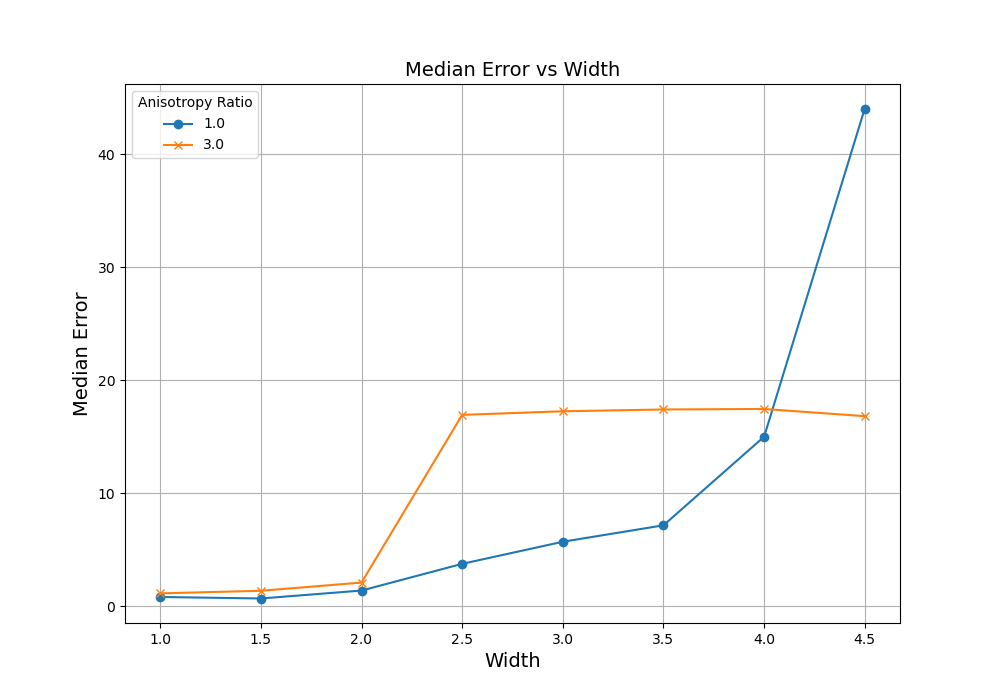

In [31]:
plt.figure(figsize=(10, 7))
plt.plot(min_error_over_sigma_AI1['width'], min_error_over_sigma_AI1['error'], marker='o', label='1.0')
plt.plot(min_error_over_sigma_AI3['width'], min_error_over_sigma_AI3['error'], marker='x', label='3.0')
plt.xlabel('Width')
plt.ylabel('Median Error')
plt.title('Median Error vs Width')
legend = plt.legend()
legend.set_title("Anisotropy Ratio")
plt.grid(True)
plt.show()

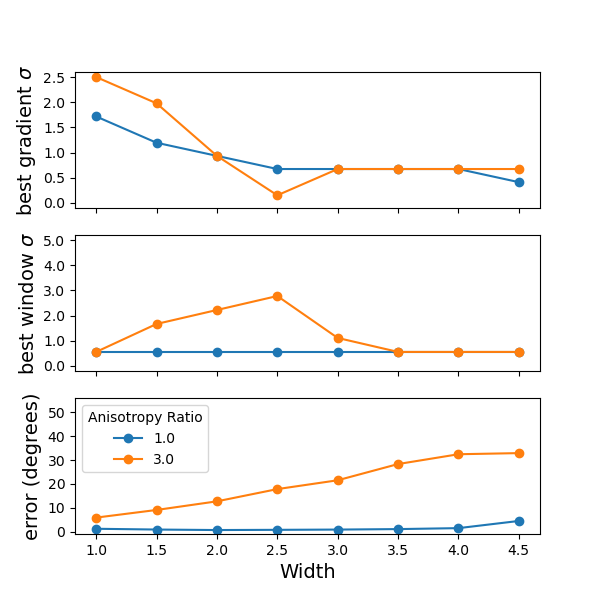

In [40]:
# plot the best sigma 1 and best sigma 2 versus the anisotropy ratio
fig, axs = plt.subplots(3, figsize=(6,6), sharex=True)
axs[0].plot(min_error_over_sigma_AI1['width'], min_error_over_sigma_AI1['derivative_sigma'], marker='o')
axs[0].plot(min_error_over_sigma_AI3['width'], min_error_over_sigma_AI3['derivative_sigma'], marker='o')
axs[0].set_ylim(-0.1,2.6)
axs[0].set_yticks(np.arange(0.0,3.0,0.5))
axs[0].set_ylabel(r'best gradient $\sigma$')
axs[1].plot(min_error_over_sigma_AI1['width'], min_error_over_sigma_AI1['tensor_sigma'], marker='o')
axs[1].plot(min_error_over_sigma_AI3['width'], min_error_over_sigma_AI3['tensor_sigma'], marker='o')
axs[1].set_ylim(-0.2,5.2)
yticklabels = [f'{y:.1f}'for y in np.arange(0.0,6.0,1.0)]
axs[1].set_yticks(np.arange(0.0,6.0,1.0))
axs[1].set_yticklabels(yticklabels)
axs[1].set_ylabel(r'best window $\sigma$')
axs[2].plot(min_error_over_sigma_AI1['width'], min_error_over_sigma_AI1['error'], marker='o', label='1.0')
axs[2].plot(min_error_over_sigma_AI3['width'], min_error_over_sigma_AI3['error'], marker='o', label='3.0')
axs[2].set_ylim(-1,56)
axs[2].set_yticks(np.arange(0,55,10))
axs[2].set_ylabel('error (degrees)')
axs[2].set_xlabel('Width')
axs[2].legend(['1.0', '3.0'], title="Anisotropy Ratio")
fig.savefig('../outputs/figures/3d_error_vs_width.png')
plt.show()

In [35]:
errors.shape

(10, 10, 8)

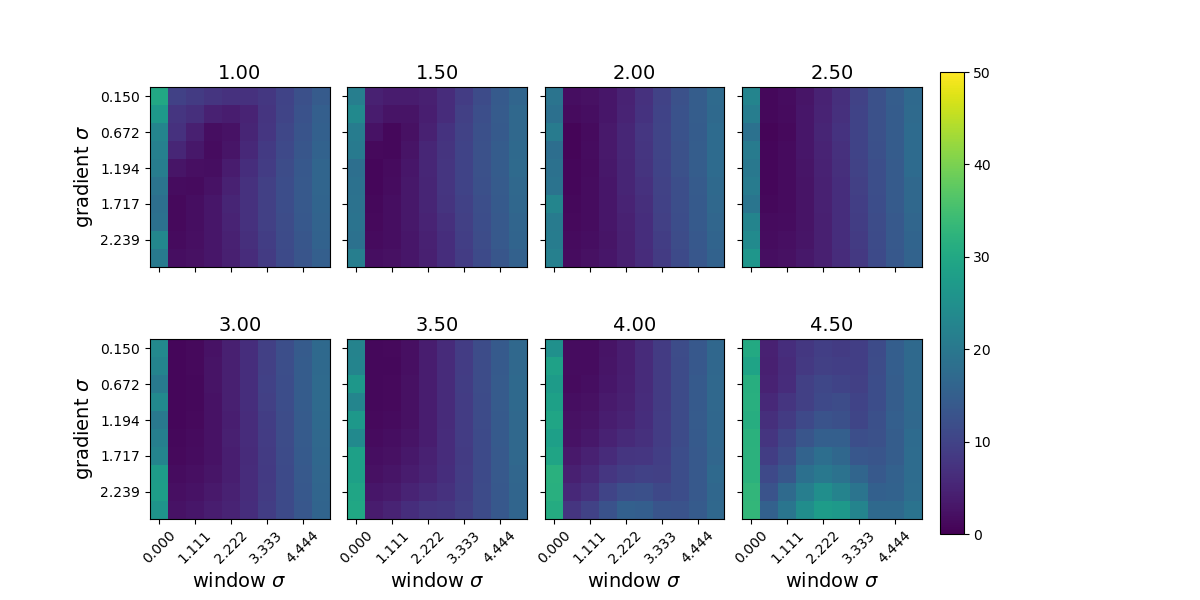

In [41]:
errors = median_error_over_angle_AI1['error'].values.reshape((len(median_error_over_angle_AI1["derivative_sigma"].unique()), len(median_error_over_angle_AI1["tensor_sigma"].unique()), len(median_error_over_angle_AI1['width'].unique())))

rows = 2
cols = 4
vm = 50
fig, axs = plt.subplots(rows,cols, figsize=(12,6), sharex=True, sharey=True)
for i,j in enumerate(median_error_over_angle_AI1['width'].unique()):
    error = errors[...,i]
    axs[i//cols,i%cols].imshow(error, vmin=0, vmax=vm)
    axs[i//cols,i%cols].set_title(f"{median_error_over_angle_AI1['width'].unique()[i]:.2f}")
    # set x tick labels
    # set the locations of the xticks and yticks
    xticklabels = [f'{t:.3f}' for t in tensor_sigmas]
    yticklabels = [f'{d:.3f}' for d in derivative_sigmas]
    axs[i//cols, i%cols].set_xticks(np.arange(len(tensor_sigmas))[::2])
    axs[i//cols, i%cols].set_yticks(np.arange(len(derivative_sigmas))[::2])
    axs[i//cols, i%cols].set_xticklabels(xticklabels[::2], rotation=45)
    axs[i//cols, i%cols].set_yticklabels(yticklabels[::2])
    if i%cols==0:
        axs[i//cols,i%cols].set_ylabel(r'gradient $\sigma$')
    if i > cols * (rows-1) - 1:
        axs[i//cols,i%cols].set_xlabel(r'window $\sigma$')
    plt.subplots_adjust(wspace=0.1, hspace=0.2)
# add colorbar to the rightmean
cbar = fig.colorbar(axs[0,0].images[0], ax=axs, location='right', pad=0.02)
# fig.suptitle('2D Three Angles')

# fig.savefig('../outputs/figures/heatmaps_2d_error_vs_width_'+DATE+'.png')
fig.savefig('../outputs/figures/heatmaps_3d_error_vs_width_'+DATE+'.png')

## 2D Phantoms

## 3D Phantoms

## Variable Mask Fraction

## 2D Phantoms

In [63]:
errors_path = "/home/brysongray/bmap/fibermetric/st_validation/sta_3d_var_mask-frac_out"
# errors_path = "/home/brysongray/bmap/fibermetric/st_validation/sta_2d_var_mask-frac_out"
errors_files = os.listdir(errors_path)
all_dataframes = []

for file in errors_files:
    file_path = os.path.join(errors_path, file)
    df = pd.read_pickle(file_path)
    all_dataframes.append(df)

combined_dataframe = pd.concat(all_dataframes, ignore_index=True)

In [64]:
combined_dataframe

,derivative_sigma,tensor_sigma,AI,period,width,angles,mask_frac,error
0,0.15,0.000000,1.0,7.0,1.0,"[[1.5468841465366623, 2.3869238852075276], [0....",0.0,27.226340
1,0.15,0.555556,1.0,7.0,1.0,"[[1.5468841465366623, 2.3869238852075276], [0....",0.0,2.522780
2,0.15,1.111111,1.0,7.0,1.0,"[[1.5468841465366623, 2.3869238852075276], [0....",0.0,9.596147
3,0.15,1.666667,1.0,7.0,1.0,"[[1.5468841465366623, 2.3869238852075276], [0....",0.0,14.169871
4,0.15,2.222222,1.0,7.0,1.0,"[[1.5468841465366623, 2.3869238852075276], [0....",0.0,17.321385
...,...,...,...,...,...,...,...,...
599795,2.50,2.777778,1.0,7.0,1.0,"[[0.5905425027017727, 0.29375493634904654], [1...",0.0,51.417839
599796,2.50,3.333333,1.0,7.0,1.0,"[[0.5905425027017727, 0.29375493634904654], [1...",0.0,33.535460
599797,2.50,3.888889,1.0,7.0,1.0,"[[0.5905425027017727, 0.29375493634904654], [1...",0.0,32.395397
599798,2.50,4.444444,1.0,7.0,1.0,"[[0.5905425027017727, 0.29375493634904654], [1...",0.0,26.837018


In [65]:
# median over angles
median_error_over_angle_AI1 = combined_dataframe[combined_dataframe["AI"]==1.0].groupby(['derivative_sigma', 'tensor_sigma', 'mask_frac'], as_index=False)['error'].median()
median_error_over_angle_AI3 = combined_dataframe[combined_dataframe["AI"]==3.0].groupby(['derivative_sigma', 'tensor_sigma', 'mask_frac'], as_index=False)['error'].median()
min_error_over_sigma_AI1 = median_error_over_angle_AI1.loc[median_error_over_angle_AI1.groupby('mask_frac')['error'].idxmin()]
min_error_over_sigma_AI3 = median_error_over_angle_AI3.loc[median_error_over_angle_AI3.groupby('mask_frac')['error'].idxmin()]
print(min_error_over_sigma_AI1)
print(min_error_over_sigma_AI3)

     derivative_sigma  tensor_sigma  mask_frac      error
310          0.933333      0.555556        0.0   1.276273
311          0.933333      0.555556        0.1   1.094564
312          0.933333      0.555556        0.2   1.151805
313          0.933333      0.555556        0.3   1.093156
314          0.933333      0.555556        0.4   1.773207
225          0.672222      1.111111        0.5   1.557897
326          0.933333      1.111111        0.6   3.529420
327          0.933333      1.111111        0.7   7.696586
718          1.977778      0.555556        0.8  10.779414
719          1.977778      0.555556        0.9  15.127037
     derivative_sigma  tensor_sigma  mask_frac      error
220          0.672222      1.111111        0.0  15.611694
441          1.194444      2.222222        0.1  13.548622
532          1.455556      1.666667        0.2  11.736922
433          1.194444      1.666667        0.3  11.312628
534          1.455556      1.666667        0.4   9.678348
535          1

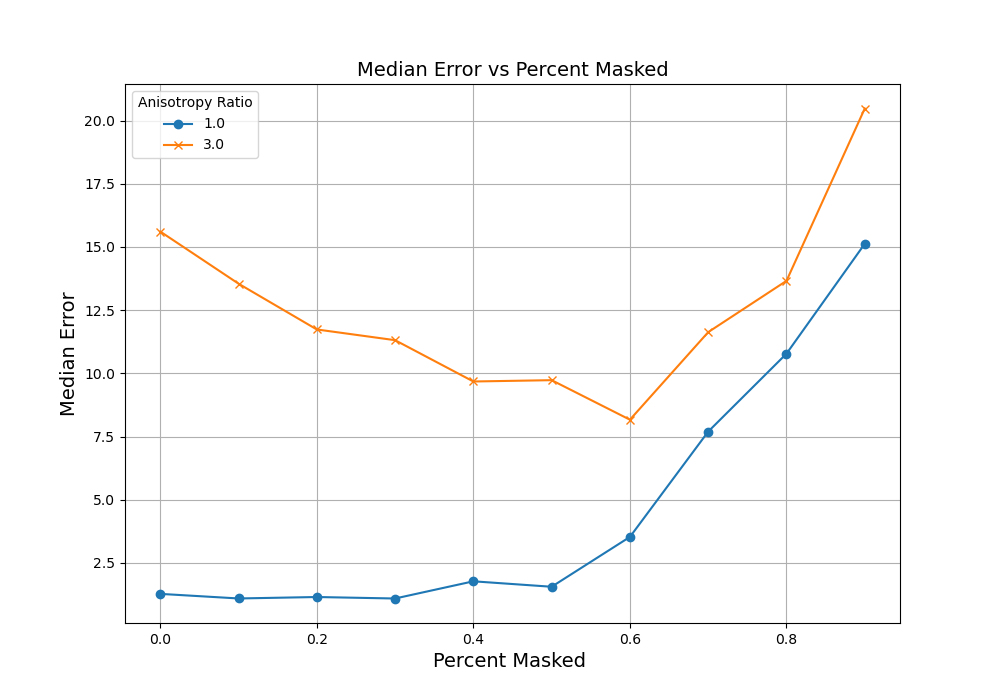

In [16]:
plt.figure(figsize=(10, 7))
plt.plot(min_error_over_sigma_AI1['mask_frac'], min_error_over_sigma_AI1['error'], marker='o', label='1.0')
plt.plot(min_error_over_sigma_AI3['mask_frac'], min_error_over_sigma_AI3['error'], marker='x', label='3.0')
plt.xlabel('Percent Masked ')
plt.ylabel('Median Error')
plt.title('Median Error vs Percent Masked')
legend = plt.legend()
legend.set_title("Anisotropy Ratio")
plt.grid(True)
plt.show()

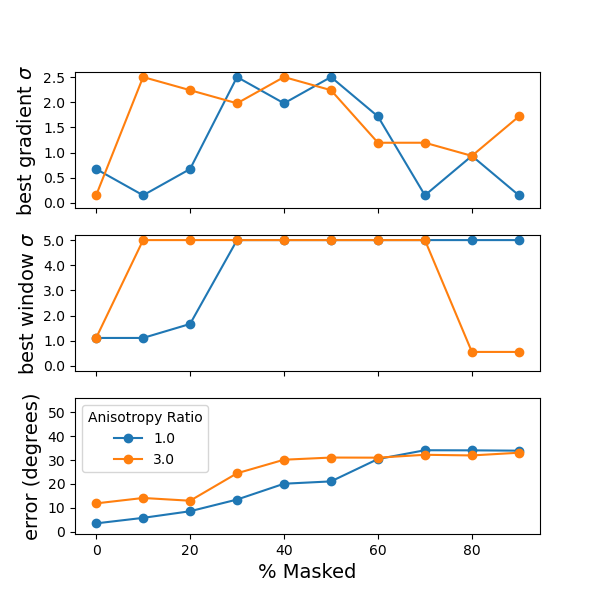

In [53]:
# plot the best sigma 1 and best sigma 2 versus the anisotropy ratio
fig, axs = plt.subplots(3, figsize=(6,6), sharex=True)
axs[0].plot(min_error_over_sigma_AI1['mask_frac']*100, min_error_over_sigma_AI1['derivative_sigma'], marker='o')
axs[0].plot(min_error_over_sigma_AI3['mask_frac']*100, min_error_over_sigma_AI3['derivative_sigma'], marker='o')
axs[0].set_ylim(-0.1,2.6)
axs[0].set_yticks(np.arange(0.0,3.0,0.5))
axs[0].set_ylabel(r'best gradient $\sigma$')
axs[1].plot(min_error_over_sigma_AI1['mask_frac']*100, min_error_over_sigma_AI1['tensor_sigma'], marker='o')
axs[1].plot(min_error_over_sigma_AI3['mask_frac']*100, min_error_over_sigma_AI3['tensor_sigma'], marker='o')
axs[1].set_ylim(-0.2,5.2)
yticklabels = [f'{y:.1f}'for y in np.arange(0.0,6.0,1.0)]
axs[1].set_yticks(np.arange(0.0,6.0,1.0))
axs[1].set_yticklabels(yticklabels)
axs[1].set_ylabel(r'best window $\sigma$')
axs[2].plot(min_error_over_sigma_AI1['mask_frac']*100, min_error_over_sigma_AI1['error'], marker='o', label='1.0')
axs[2].plot(min_error_over_sigma_AI3['mask_frac']*100, min_error_over_sigma_AI3['error'], marker='o', label='3.0')
axs[2].set_ylim(-1,56)
axs[2].set_yticks(np.arange(0,55,10))
axs[2].set_ylabel('error (degrees)')
axs[2].set_xlabel('% Masked')
axs[2].legend(['1.0', '3.0'], title="Anisotropy Ratio")
fig.savefig('../outputs/figures/2d_error_vs_mask_frac.png')
plt.show()

In [61]:
plt.close("all")

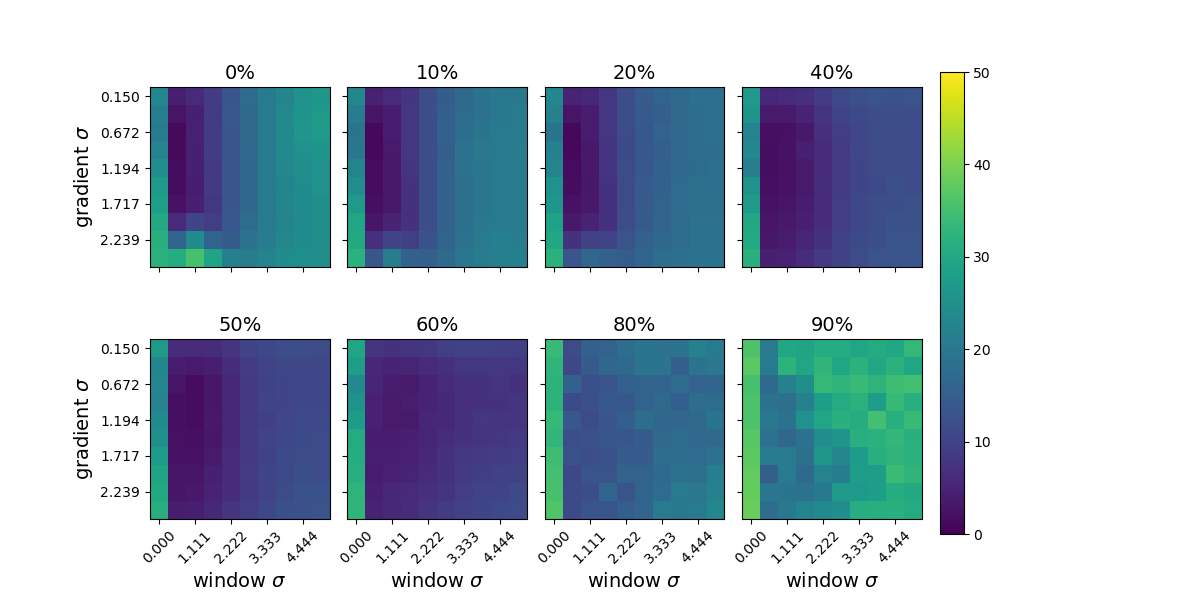

In [66]:
errors = median_error_over_angle_AI1['error'].values.reshape((len(median_error_over_angle_AI1["derivative_sigma"].unique()), len(median_error_over_angle_AI1["tensor_sigma"].unique()), len(median_error_over_angle_AI1['mask_frac'].unique())))

rows = 2
cols = 4
vm = 50
fig, axs = plt.subplots(rows,cols, figsize=(12,6), sharex=True, sharey=True)
for i,j in enumerate([0,1,2,4,5,6,8,9]):
    error = errors[...,j]
    axs[i//cols,i%cols].imshow(error, vmin=0, vmax=vm)
    axs[i//cols,i%cols].set_title(f"{int(median_error_over_angle_AI1['mask_frac'].unique()[j]*100)}%")
    # set x tick labels
    # set the locations of the xticks and yticks
    xticklabels = [f'{t:.3f}' for t in tensor_sigmas]
    yticklabels = [f'{d:.3f}' for d in derivative_sigmas]
    axs[i//cols, i%cols].set_xticks(np.arange(len(tensor_sigmas))[::2])
    axs[i//cols, i%cols].set_yticks(np.arange(len(derivative_sigmas))[::2])
    axs[i//cols, i%cols].set_xticklabels(xticklabels[::2], rotation=45)
    axs[i//cols, i%cols].set_yticklabels(yticklabels[::2])
    if i%cols==0:
        axs[i//cols,i%cols].set_ylabel(r'gradient $\sigma$')
    if i > cols * (rows-1) - 1:
        axs[i//cols,i%cols].set_xlabel(r'window $\sigma$')
    plt.subplots_adjust(wspace=0.1, hspace=0.2)
# add colorbar to the rightmean
cbar = fig.colorbar(axs[0,0].images[0], ax=axs, location='right', pad=0.02)
# fig.suptitle('2D Three Angles')

# fig.savefig('../outputs/figures/heatmaps_2d_error_vs_width_'+DATE+'.png')
fig.savefig('../outputs/figures/heatmaps_3d_error_vs_mask_frac_'+DATE+'.png')

## 3D Phantoms